[*********************100%***********************]  1 of 1 completed


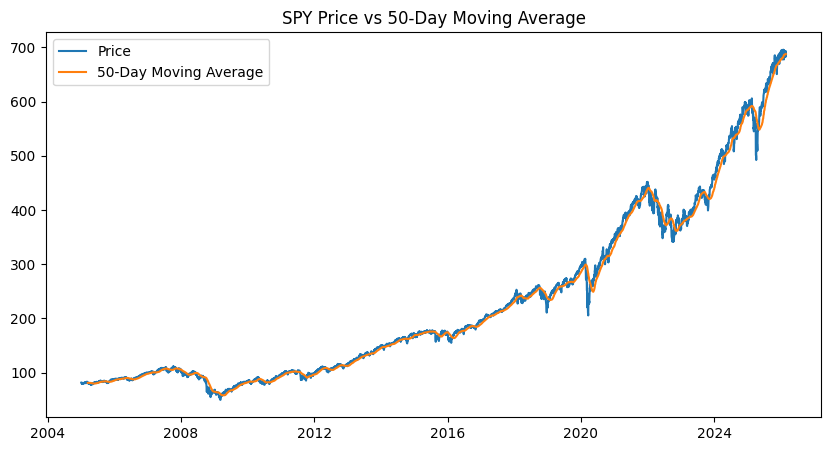

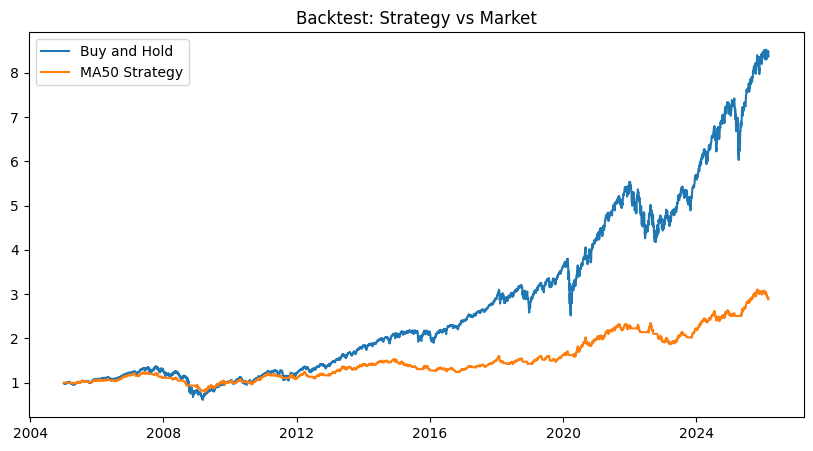

Market Sharpe: 0.62
Strategy Sharpe: 0.52


In [ ]:
# ============================
# VIDEO 4 - BASIC BACKTESTING
# JCAnalyticsFinanzas
# ============================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Download Data
# ----------------------------

ticker = "SPY"

data = yf.download(
    ticker,
    start="2005-01-01",
    auto_adjust=True   # Avoid warning and use adjusted prices
)

# If columns are MultiIndex, flatten them
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# ----------------------------
# Calculate Moving Average
# ----------------------------

data["MA50"] = data["Close"].rolling(window=50).mean()

# ----------------------------
# Generate Signal
# ----------------------------

data["Signal"] = np.where(data["Close"] > data["MA50"], 1, 0)

# ----------------------------
# Compute Returns
# ----------------------------

data["Returns"] = data["Close"].pct_change()

# Strategy returns (avoid lookahead bias)
data["Strategy"] = data["Returns"] * data["Signal"].shift(1)

# ----------------------------
# Equity Curves
# ----------------------------

data["Cumulative_Market"] = (1 + data["Returns"]).cumprod()
data["Cumulative_Strategy"] = (1 + data["Strategy"]).cumprod()

# ----------------------------
# Plot 1: Price and MA
# ----------------------------

plt.figure(figsize=(10,5))
plt.plot(data["Close"], label="Price")
plt.plot(data["MA50"], label="50-Day Moving Average")
plt.title("SPY Price vs 50-Day Moving Average")
plt.legend()
plt.show()

# ----------------------------
# Plot 2: Equity Curve
# ----------------------------

plt.figure(figsize=(10,5))
plt.plot(data["Cumulative_Market"], label="Buy and Hold")
plt.plot(data["Cumulative_Strategy"], label="MA50 Strategy")
plt.title("Backtest: Strategy vs Market")
plt.legend()
plt.show()

# ----------------------------
# Performance Metrics
# ----------------------------

def sharpe_ratio(returns):
    return np.sqrt(252) * returns.mean() / returns.std()

market_sharpe = sharpe_ratio(data["Returns"].dropna())
strategy_sharpe = sharpe_ratio(data["Strategy"].dropna())

print("Market Sharpe:", round(market_sharpe, 2))
print("Strategy Sharpe:", round(strategy_sharpe, 2))

📊 Backtest Interpretation

The buy-and-hold strategy significantly outperformed the 50-day moving average strategy in terms of total return.

From 2005 to the present:

Buy and Hold grew to approximately 8.5x

The MA50 strategy grew to approximately 3x

This is not surprising. The U.S. equity market has experienced a strong long-term bull trend since 2009, and trend-following strategies often underperform during sustained upward movements because they exit during temporary pullbacks.

📈 Risk-Adjusted Performance

Sharpe Ratios:

Market: 0.62

Strategy: 0.52

The market delivered a higher risk-adjusted return over this period.

This highlights an important lesson:

A simple rule-based strategy does not automatically outperform the market.

Backtesting helps us verify whether an idea adds value or simply reduces exposure.

🧠 Key Insight

The purpose of this backtest is not to "beat the market" with a simple rule.

It is to demonstrate the importance of:

Testing before investing

Avoiding emotional decision-making

Validating strategies with historical data

Without backtesting, investing becomes speculation.